In [ ]:
1.Perform exploratory data analysis (EDA) to gain insights into the dataset. 
Provide visualizations and summary statistics of the variables. 
Pre-process the data to apply the MLR.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/Users/Harshitha/Downloads/Multiple Linear Regression (1)/ToyotaCorolla - MLR.csv")

df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [5]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [6]:
df = df.dropna()

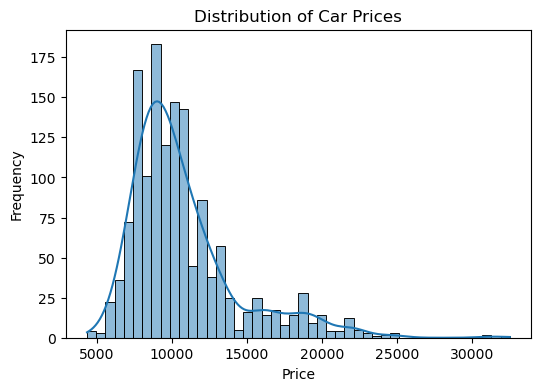

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [8]:
df = pd.get_dummies(df, columns=['Fuel_Type'], drop_first=True)

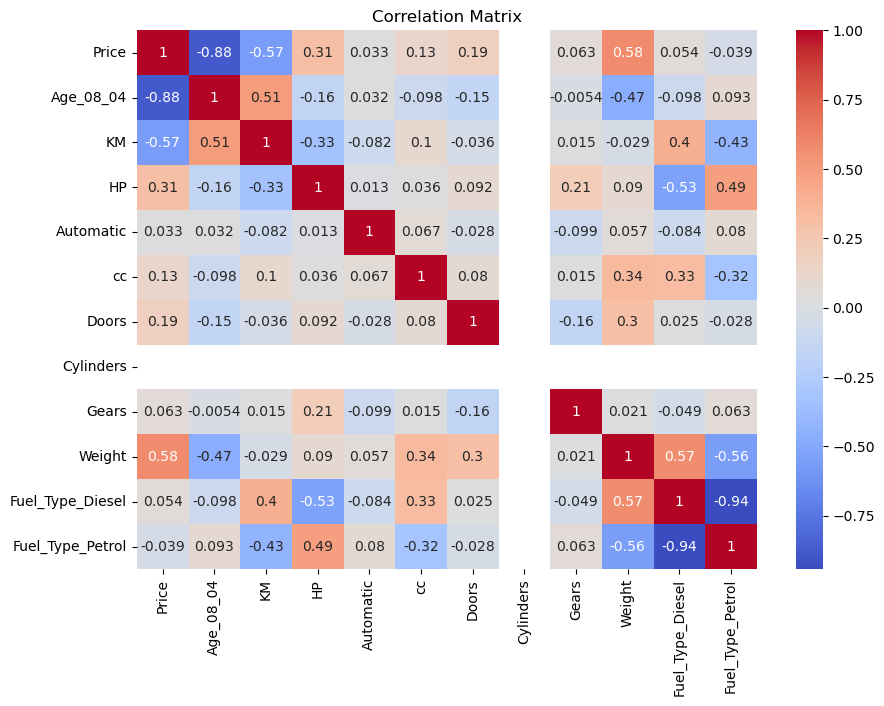

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

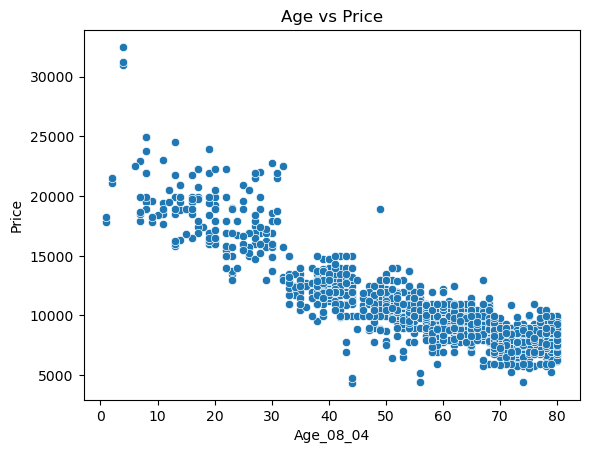

In [10]:
sns.scatterplot(x='Age_08_04', y='Price', data=df)
plt.title("Age vs Price")
plt.show()

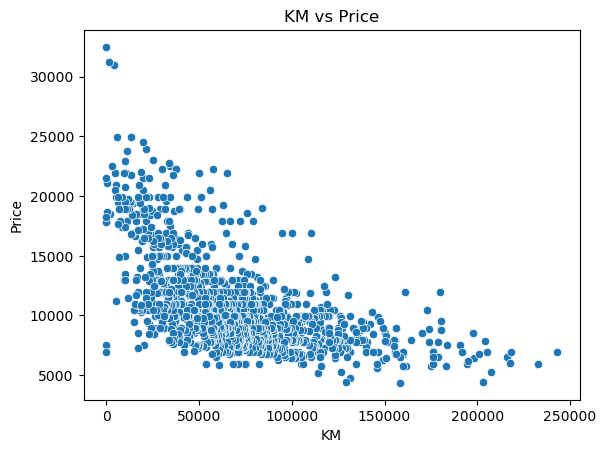

In [11]:
sns.scatterplot(x='KM', y='Price', data=df)
plt.title("KM vs Price")
plt.show()

In [ ]:
2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [15]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
3.Build a multiple linear regression model using the training dataset. 
Interpret the coefficients of the model.
Build a minimum of 3 different models.

In [19]:
from sklearn.linear_model import LinearRegression

model1 = LinearRegression()

model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

In [20]:
coefficients = pd.DataFrame(model1.coef_, X.columns, columns=['Coefficient'])

print(coefficients)

                   Coefficient
Age_08_04        -2.267295e+03
KM               -6.116544e+02
HP                2.083499e+02
Automatic         3.439713e+01
cc               -1.416192e+01
Doors            -5.746780e+01
Cylinders        -8.526513e-14
Gears             1.093404e+02
Weight            1.316818e+03
Fuel_Type_Diesel -2.172217e+01
Fuel_Type_Petrol  4.580477e+02


In [21]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1)

ridge_model.fit(X_train, y_train)

y_pred2 = ridge_model.predict(X_test)

In [22]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

y_pred3 = lasso_model.predict(X_test)

In [ ]:
4.Evaluate the performance of the model using appropriate evaluation metrics on the testing dataset.

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [24]:
def evaluate_model(y_test, y_pred):

    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

In [25]:
evaluate_model(y_test, y_pred1)

R2 Score: 0.834888804061108
MAE: 990.8872739193971
MSE: 2203043.823143705
RMSE: 1484.2654153296521


In [26]:
evaluate_model(y_test, y_pred2)

R2 Score: 0.8350462635431573
MAE: 990.8591771287416
MSE: 2200942.8745232844
RMSE: 1483.5575063081594


In [27]:
evaluate_model(y_test, y_pred3)

R2 Score: 0.8349116135580271
MAE: 990.9001968731633
MSE: 2202739.480842683
RMSE: 1484.1628889184242
